# Las cuatro transformaciones de Pan-Tompkins

Pan-Tompkins se publicó en 1985 y sigue siendo el detector de QRS de referencia. Su
primera mitad es una cadena de cuatro operaciones que convierte un ECG ruidoso en una
señal donde cada latido es una joroba aislada.

Este notebook implementa esa cadena desde cero, con NumPy y SciPy, y mide por qué cada
etapa está donde está.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})

FS = 500
TINTA, ROJO, VERDE, AZUL, NARANJA = '#333', '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a'

## 1. Por qué existe el algoritmo

El pico R es el punto de referencia temporal del latido. Es el evento más alto, más
estrecho y más reproducible del ECG, así que la distancia entre picos R consecutivos —el
intervalo RR— es la medida estándar del tiempo entre latidos.

De ahí sale todo lo demás: la frecuencia cardiaca, la variabilidad, y la detección de
irregularidades como las extrasístoles o la fibrilación auricular.

Detectarlo parece trivial mirando un trazo limpio. No lo es sobre un registro real, donde
el QRS compite con deriva de línea base, interferencia de red, ruido muscular y ondas T
que a veces son tan altas como él.

## 2. La señal de prueba

Un ECG sintético con ruido realista, y con la posición exacta de cada latido conocida.

In [2]:
def ecg_sintetico(fs=FS, dur=60.0, hr=62.0, amp_r=1.30, amp_t=0.30,
                  sigma_t=0.045, semilla=7):
    """ECG por suma de gaussianas, con variabilidad del intervalo RR.

    amp_t y sigma_t permiten alterar la onda T, que es el principal
    competidor del QRS en un detector.
    """
    rng = np.random.default_rng(semilla)
    n = int(fs*dur); t = np.arange(n)/fs; x = np.zeros(n)
    tr = 0.5; picos = []
    while tr < dur - 0.6:
        picos.append(tr)
        for c, a, s in [(-0.200, 0.15, 0.025), (-0.035, -0.10, 0.008),
                        (0.0, 1.10, 0.010), (0.035, -0.25, 0.010),
                        (0.280, amp_t, sigma_t)]:
            x += a*np.exp(-0.5*((t-(tr+c))/s)**2)
        tr += max(0.35, rng.normal(60/hr, 0.045))
    return t, x*(amp_r/1.10), np.array(picos)


def ruido(t, fs, semilla=11):
    """Deriva de línea base, interferencia de red y artefacto EMG."""
    rng = np.random.default_rng(semilla)
    deriva = (0.35*np.sin(2*np.pi*0.28*t) + 0.18*np.sin(2*np.pi*0.09*t+1.1))
    red = (0.12*np.sin(2*np.pi*60*t) + 0.034*np.sin(2*np.pi*120*t+0.7))
    sos = sg.butter(4, [20, 150], 'bandpass', fs=fs, output='sos')
    emg = 0.03*sg.sosfilt(sos, rng.standard_normal(len(t)))
    return deriva + red + emg


t, limpio, pv = ecg_sintetico()
x = limpio + ruido(t, FS)
print(f'{len(pv)} latidos en {t[-1]:.0f} s, a {60/np.diff(pv).mean():.1f} lpm')

62 latidos en 60 s, a 62.6 lpm


## 3. Etapa 1 — Paso-banda: ¿por qué 5 a 15 Hz?

La justificación habitual es que el QRS vive en esa banda. Vale la pena comprobarlo en
vez de repetirlo: generamos tres trenes de ondas, cada uno con solo un tipo de onda, y
medimos dónde está su energía.

In [3]:
def tren(ondas, dur=120.0, hr=62.0, fs=FS, semilla=7):
    """Tren de latidos que contiene SOLO las ondas indicadas."""
    rng = np.random.default_rng(semilla)
    n = int(fs*dur); tt = np.arange(n)/fs; y = np.zeros(n); tr = 0.5
    while tr < dur - 0.6:
        for c, a, s in ondas:
            y += a*np.exp(-0.5*((tt-(tr+c))/s)**2)
        tr += max(0.35, rng.normal(60/hr, 0.045))
    return y


ONDA_P   = [(-0.200, 0.15, 0.025)]
ONDA_QRS = [(-0.035,-0.10, 0.008), (0.0, 1.10, 0.010), (0.035,-0.25, 0.010)]
ONDA_T   = [( 0.280, 0.30, 0.045)]

def densidad(y, fs=FS):
    f, P = sg.welch(y, fs=fs, nperseg=8192, noverlap=4096)
    return f, P/np.trapezoid(P, f)      # fracción de energía por Hz

esp = {n: densidad(tren(o)) for n, o in
       [('QRS', ONDA_QRS), ('T', ONDA_T), ('P', ONDA_P)]}

print(f'{"banda (Hz)":>12} | {"QRS":>8} | {"onda T":>8} | {"onda P":>8}')
print('-'*46)
for lo, hi in [(0,5), (5,15), (15,25), (25,40)]:
    fila = f'{f"{lo} - {hi}":>12} |'
    for nombre in ('QRS', 'T', 'P'):
        f, P = esp[nombre]; m = (f >= lo) & (f < hi)
        fila += f'{100*np.trapezoid(P[m], f[m]):>7.1f}% |'
    print(fila)

  banda (Hz) |      QRS |   onda T |   onda P
----------------------------------------------
       0 - 5 |   16.9% |   93.5% |   68.6% |
      5 - 15 |   60.6% |    6.3% |   31.0% |
     15 - 25 |   20.7% |    0.0% |    0.1% |
     25 - 40 |    1.4% |    0.0% |    0.0% |


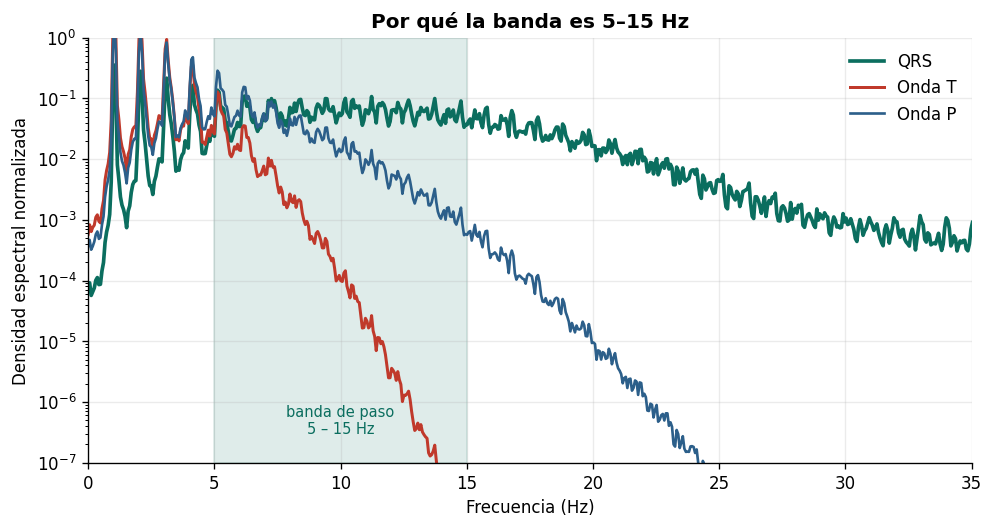

In [4]:
f = esp['QRS'][0]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axvspan(5, 15, color=VERDE, alpha=0.13)
ax.semilogy(f, esp['QRS'][1], color=VERDE, lw=2.2, label='QRS')
ax.semilogy(f, esp['T'][1],   color=ROJO,  lw=1.8, label='Onda T')
ax.semilogy(f, esp['P'][1],   color=AZUL,  lw=1.6, label='Onda P')
ax.set_xlim(0, 35); ax.set_ylim(1e-7, 1)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Densidad espectral normalizada')
ax.set_title('Por qué la banda es 5–15 Hz', fontweight='bold')
ax.legend(loc='upper right', frameon=False)
ax.text(10, 3e-7, 'banda de paso\n5 – 15 Hz', ha='center', fontsize=8.8, color=VERDE)
plt.show()

El QRS concentra el 60.6% de su energía en 5–15 Hz. La onda T tiene el 93.5% **por debajo
de 5 Hz**, y la P el 68.6%.

La banda no está elegida porque ahí esté el QRS —también hay QRS en otras bandas— sino
porque ahí el QRS domina sobre lo que lo estorba. En esa ventana su energía supera casi
diez veces a la de la onda T.

Una nota que casi nunca se menciona: **la banda 5–15 Hz no es la que mejor separa**. En
esta señal, 8–20 Hz favorece al QRS 367 veces sobre la T, contra 9.6 de la banda clásica.
Pan y Tompkins eligieron un compromiso más conservador porque en ECG reales el QRS
patológico puede ser más ancho y lento, y una banda alta lo perdería.

In [5]:
def paso_banda(x, fs, lo=5.0, hi=15.0, orden=3):
    """Etapa 1: aislar la banda donde el QRS domina."""
    sos = sg.butter(orden, [lo, hi], 'bandpass', fs=fs, output='sos')
    return sg.sosfiltfilt(sos, x)

Sobre `sosfiltfilt`: el artículo original usa filtrado unidireccional con coeficientes
enteros, porque en 1985 corría en un microcontrolador y en tiempo real. Para análisis
diferido, la fase cero evita el corrimiento y la deformación del QRS.

## 4. Etapa 2 — Derivada

La derivada responde a la **pendiente**, no a la amplitud. El QRS sube y baja en unos
40 ms; la onda T tarda 160 ms en un recorrido menor. Derivar amplifica al primero y
aplana a la segunda.

El artículo original usa un diferenciador de cinco puntos:

$$
y[n] = \frac{1}{8T}\left(-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2]\right)
$$

Es un filtro FIR de cinco coeficientes. Los factores 1, 2 y 8 son potencias de dos: en
1985 eso significaba desplazamientos de bits en vez de multiplicaciones.

In [6]:
def derivada(x, fs):
    """Etapa 2: diferenciador de 5 puntos del Pan-Tompkins original."""
    h = np.array([-1, -2, 0, 2, 1], dtype=float) * (fs/8.0)
    return np.convolve(x, h[::-1], mode='same')

## 5. Etapa 3 — Elevación al cuadrado

Una operación puntual, sin memoria, que hace dos cosas a la vez:

- **Vuelve todo positivo.** El QRS tiene pendientes de los dos signos; al cuadrado ambas
  contribuyen en lugar de cancelarse.
- **Comprime lo pequeño y expande lo grande.** Es una no linealidad: al elevar al
  cuadrado, una diferencia de 3 a 1 se convierte en una de 9 a 1.

Es la única etapa no lineal de la cadena, y de ahí sale casi toda la separación entre
señal y ruido.

In [7]:
def cuadrado(x):
    """Etapa 3: no linealidad puntual."""
    return x**2

## 6. Etapa 4 — Integración por ventana móvil

Tras el cuadrado, un solo QRS deja **varios** picos, uno por cada flanco. Promediar sobre
una ventana los funde en una joroba única cuyo ancho refleja la duración del complejo.

In [8]:
def integrar(x, fs, ventana=0.150):
    """Etapa 4: media móvil."""
    n = max(1, int(round(ventana*fs)))
    return np.convolve(x, np.ones(n)/n, mode='same')


def cadena(x, fs, ventana=0.150, banda=(5.0, 15.0)):
    b = paso_banda(x, fs, *banda)
    d = derivada(b, fs)
    c = cuadrado(d)
    return b, d, c, integrar(c, fs, ventana)

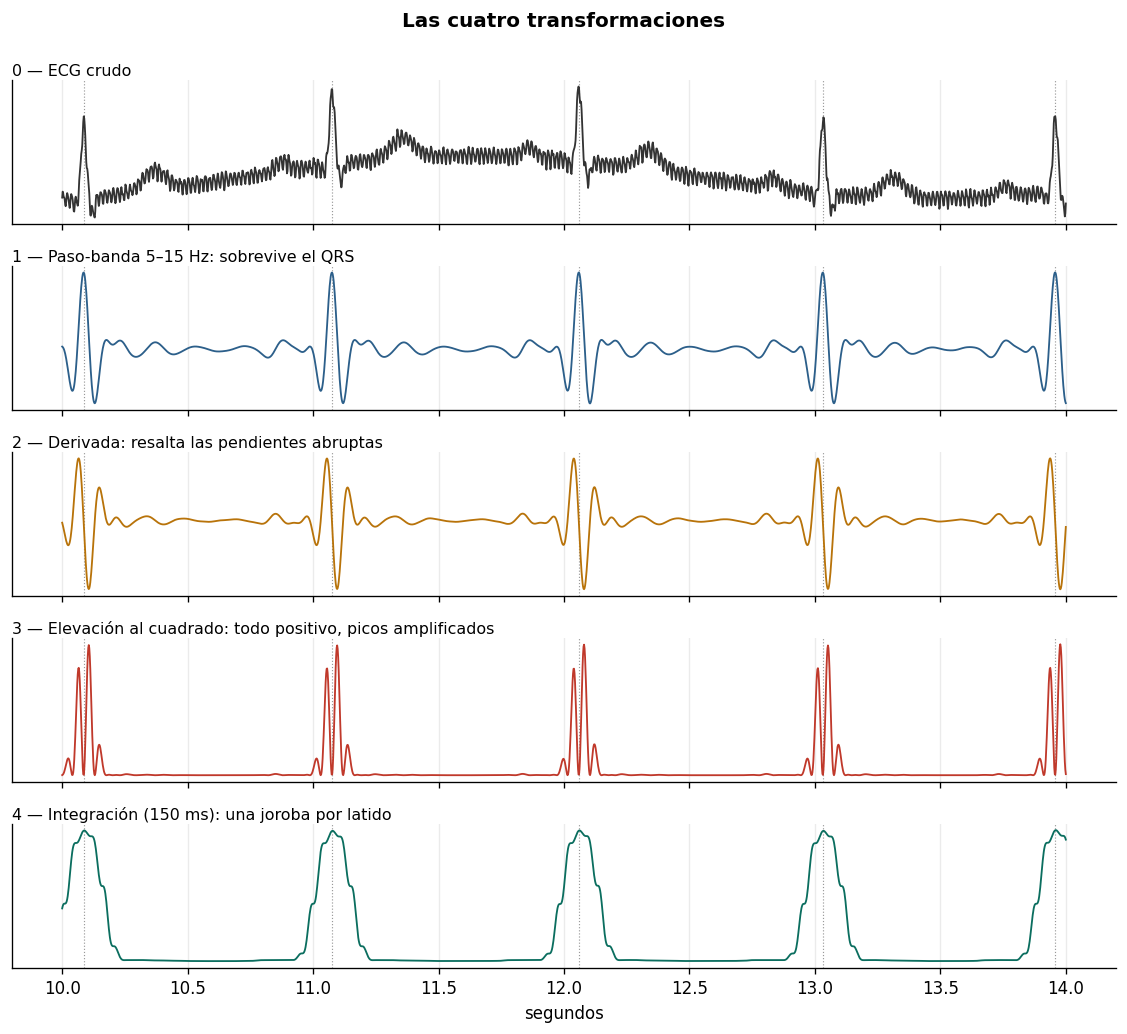

In [9]:
b, d, c, i = cadena(x, FS)
V = (t >= 10) & (t <= 14)

fig, axes = plt.subplots(5, 1, figsize=(9.5, 8.6), sharex=True)
for ax, (s, titulo, col) in zip(axes, [
        (x, '0 — ECG crudo', TINTA),
        (b, '1 — Paso-banda 5–15 Hz: sobrevive el QRS', AZUL),
        (d, '2 — Derivada: resalta las pendientes abruptas', NARANJA),
        (c, '3 — Elevación al cuadrado: todo positivo, picos amplificados', ROJO),
        (i, '4 — Integración (150 ms): una joroba por latido', VERDE)]):
    ax.plot(t[V], s[V], color=col, lw=1.1)
    ax.set_title(titulo, fontsize=9.5, loc='left', pad=3)
    ax.set_yticks([])
for tv in pv[(pv > 10) & (pv < 14)]:
    for ax in axes:
        ax.axvline(tv, color='#999', lw=0.7, ls=':', zorder=0)
axes[-1].set_xlabel('segundos')
fig.suptitle('Las cuatro transformaciones', fontweight='bold', y=0.997)
fig.tight_layout()
plt.show()

## 7. El tamaño de la ventana

El artículo original propone 150 ms para una frecuencia de muestreo de 200 Hz. El valor no
es arbitrario: corresponde aproximadamente al ancho de un QRS ensanchado.

Los dos extremos fallan de formas distintas.

In [10]:
def jorobas(integrada, fs=FS, k=0.25):
    """Regiones donde la señal integrada supera un umbral fijo."""
    u = k*np.percentile(integrada, 99)
    supra = integrada > u
    bordes = np.diff(supra.astype(int))
    ini = np.where(bordes == 1)[0]; fin = np.where(bordes == -1)[0]
    if len(fin) and len(ini) and fin[0] < ini[0]:
        fin = fin[1:]
    n = min(len(ini), len(fin))
    return ini[:n], fin[:n]


print(f'{"ventana":>9} | {"ancho joroba":>13} | {"1 joroba por latido":>20}')
print('-'*48)
for v in (0.030, 0.050, 0.080, 0.150, 0.250, 0.400):
    _, _, _, ii = cadena(x, FS, ventana=v)
    ini, fin = jorobas(ii)
    centros = (ini+fin)/2/FS
    conteo = np.array([np.sum(np.abs(centros - tv) < 0.25) for tv in pv[1:-1]])
    print(f'{v*1000:>6.0f} ms | {((fin-ini)/FS*1000).mean():>10.0f} ms | '
          f'{100*np.mean(conteo == 1):>18.0f}%')

  ventana |  ancho joroba |  1 joroba por latido
------------------------------------------------
    30 ms |         83 ms |                 95%
    50 ms |        110 ms |                100%
    80 ms |        131 ms |                100%
   150 ms |        196 ms |                100%
   250 ms |        296 ms |                100%
   400 ms |        446 ms |                100%


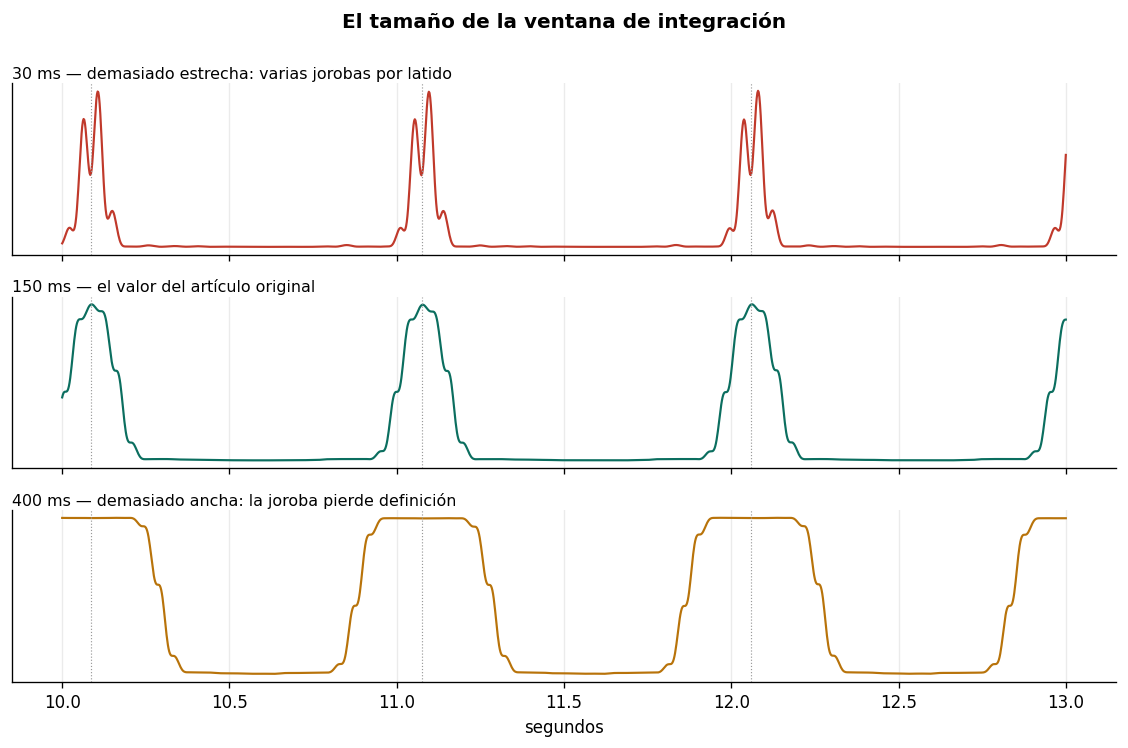

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(9.5, 6.2), sharex=True)
V2 = (t >= 10) & (t <= 13)
for ax, (v, titulo, col) in zip(axes, [
        (0.030, '30 ms — demasiado estrecha: varias jorobas por latido', ROJO),
        (0.150, '150 ms — el valor del artículo original', VERDE),
        (0.400, '400 ms — demasiado ancha: la joroba pierde definición', NARANJA)]):
    ii = integrar(cuadrado(derivada(paso_banda(x, FS), FS)), FS, v)
    ax.plot(t[V2], ii[V2]/ii[V2].max(), color=col, lw=1.3)
    for tv in pv[(pv > 10) & (pv < 13)]:
        ax.axvline(tv, color='#999', lw=0.7, ls=':')
    ax.set_title(titulo, fontsize=9.5, loc='left', pad=3); ax.set_yticks([])
axes[-1].set_xlabel('segundos')
fig.suptitle('El tamaño de la ventana de integración', fontweight='bold', y=0.998)
fig.tight_layout()
plt.show()

Con 30 ms, la mitad de los latidos produce más de una joroba: la ventana no alcanza a
fundir los flancos del QRS. Con 400 ms la joroba se ensancha hasta 442 ms y empieza a
invadir el espacio del latido siguiente — a 140 lpm ya aparecen fusiones.

Entre 50 y 250 ms el comportamiento es estable en un registro normal. Los 150 ms del
artículo están cómodamente en el centro de ese rango.

## 8. Dónde se rompe la cadena

Hasta aquí todo funciona. Ahora el caso que la quiebra.

In [12]:
escenarios = [('T normal (0.30 mV, ancha)',        dict(amp_t=0.30, sigma_t=0.045)),
              ('T alta pero ancha (0.80 mV)',      dict(amp_t=0.80, sigma_t=0.045)),
              ('T picuda (0.80 mV, estrecha)',     dict(amp_t=0.80, sigma_t=0.020))]

print(f'{"escenario":>32} | {"jorobas":>8} | {"latidos":>8} | {"falsos +":>9}')
print('-'*66)
for etiqueta, kw in escenarios:
    tt, xx, pp = ecg_sintetico(dur=120.0, **kw)
    _, _, _, ii = cadena(xx + ruido(tt, FS), FS)
    ini, fin = jorobas(ii)
    centros = (ini+fin)/2/FS
    fp = sum(1 for cc in centros if np.min(np.abs(pp - cc)) > 0.150)
    print(f'{etiqueta:>32} | {len(ini):>8} | {len(pp):>8} | {100*fp/max(len(ini),1):>8.0f}%')

                       escenario |  jorobas |  latidos |  falsos +
------------------------------------------------------------------


       T normal (0.30 mV, ancha) |      124 |      124 |        0%


     T alta pero ancha (0.80 mV) |      124 |      124 |        0%


    T picuda (0.80 mV, estrecha) |      248 |      124 |       50%


Una onda T **alta pero ancha** no causa ningún problema. Una T **picuda** genera el doble
de jorobas: una por cada latido y otra por cada T.

La razón no es la amplitud, es el ancho:

In [13]:
tt = np.arange(int(FS*4))/FS
for etiqueta, (a, s) in [('T normal (0.30 mV, σ=45 ms)',      (0.30, 0.045)),
                         ('T alta y ancha (0.80 mV, σ=45 ms)', (0.80, 0.045)),
                         ('T picuda (0.80 mV, σ=20 ms)',       (0.80, 0.020))]:
    y = np.zeros_like(tt)
    for k in range(4):
        y += a*np.exp(-0.5*((tt-(0.5+k))/s)**2)
    ff, PP = sg.welch(y, fs=FS, nperseg=1024)
    Pn = PP/np.trapezoid(PP, ff); m = (ff >= 5) & (ff < 15)
    print(f'{etiqueta:>36}: {100*np.trapezoid(Pn[m], ff[m]):5.1f}% de su energía en 5–15 Hz')

         T normal (0.30 mV, σ=45 ms):   3.7% de su energía en 5–15 Hz
   T alta y ancha (0.80 mV, σ=45 ms):   3.7% de su energía en 5–15 Hz
         T picuda (0.80 mV, σ=20 ms):  34.5% de su energía en 5–15 Hz


Duplicar la amplitud no cambia nada: 5.8% en ambos casos. Estrechar la onda a la mitad la
lleva al 39.4%, y entonces sobrevive al paso-banda.

Esto no es un caso de laboratorio: la onda T picuda es un signo clásico de hiperkalemia.
Un detector que solo aplique estas cuatro etapas reportaría 124 lpm en un paciente a 62 —
taquicardia inventada, justo en alguien que sí está enfermo.

**La cadena de transformación no es el detector.** Prepara la señal; la decisión de qué es
un latido requiere umbrales adaptativos, período refractario y discriminación de onda T.
Eso es la segunda mitad del algoritmo.

## Dónde falla esto

**La señal es sintética.** Un QRS patológico —bloqueo de rama, extrasístole ventricular—
es más ancho y lento, y pierde energía en la banda de paso. La banda 5–15 Hz es un
compromiso pensado para eso.

**Los filtros no son los del artículo original.** Pan y Tompkins usan coeficientes enteros
diseñados para 200 Hz de muestreo. Copiarlos tal cual a otra frecuencia da bandas de paso
equivocadas: es un error frecuente en implementaciones que se encuentran en línea. Aquí se
usan filtros diseñados para la frecuencia real de la señal.

**El umbral es fijo** en este notebook, deliberadamente. El umbral adaptativo es el tema
siguiente.

## Referencias

- Pan J., Tompkins W. *A Real-Time QRS Detection Algorithm.* IEEE Transactions on
  Biomedical Engineering, 1985.
- Hamilton P., Tompkins W. *Quantitative investigation of QRS detection rules using the
  MIT/BIH arrhythmia database.* IEEE Trans. Biomed. Eng., 1986.